fasterrcnn_resnet50_fpn_v2 및 FasterRCNN_ResNet50_FPN_V2_Weights는 Faster R-CNN 모델을 위한 모듈입니다. fasterrcnn_resnet50_fpn_v2 함수를 사용하여 Faster R-CNN 모델을 로드합니다. 이 모델은 ResNet-50 백본과 Feature Pyramid Network (FPN)을 사용합니다. weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT는 모델 가중치를 사전 학습된 가중치로 설정합니다.

Faster R-CNN ResNet50 FPN v2의 “DEFAULT weights”는 보통 COCO 데이터셋(일상 사물 80종) 같은 표준 객체탐지 데이터로 학습된 가중치

torch: 텐서/모델/학습의 기본 엔진
torchvision: 비전(이미지)용 모델/데이터/변환 모음
fasterrcnn_resnet50_fpn_v2: 객체탐지 모델 (박스 + 클래스)
Weights.DEFAULT: “학습된 가중치(뇌)”를 같이 가져오겠다는 선택지

디바이스 설정에서 GPU 있으면 GPU로, 없으면 CPU로. 속도 차이가 큼 (탐지는 특히).

In [2]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights

import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

# 디바이스 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 로드 및 설정 pretrained mode 소환
model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT)
#학습 시켜둔 가중치를 같이 가지고 와서 써라.
model.eval().to(device) #시험모드(드롭아웃, 배치 정규화 동작이 안정적으로 고정, 추론용)


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       

클래스가 많기 때문에 리스트 형태로 class_names에 저장하여 사용합니다. Faster R-CNN에서 첫 번째 클래스는 배경으로 사용됩니다. 또한, 클래스별 바운딩 박스 색깔을 다르게 설정하기 위해 colors = np.random.uniform(0, 255, size=(len(class_names), 3))라는 코드를 사용합니다.

class_names 리스트도 COCO 라벨 목록과 맞물림.
label=17이면 "cat" 이런 식으로 바로 이름이 나오는 거야.

In [3]:
import numpy as np

# 랜덤 시드
np.random.seed(100)

class_names = [
    "__background__", "person", "bicycle", "car", "motorcycle", "airplane", "bus",
    "train", "truck", "boat", "traffic light", "fire hydrant", "N/A", "stop sign",
    "parking meter", "bench", "bird", "cat", "dog", "horse", "sheep", "cow",
    "elephant", "bear", "zebra", "giraffe", "N/A", "backpack", "umbrella", "N/A", "N/A",
    "handbag", "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball",
    "kite", "baseball bat", "baseball glove", "skateboard", "surfboard", "tennis racket",
    "bottle", "N/A", "wine glass", "cup", "fork", "knife", "spoon", "bowl",
    "banana", "apple", "sandwich", "orange", "broccoli", "carrot", "hot dog", "pizza",
    "donut", "cake", "chair", "couch", "potted plant", "bed", "N/A", "dining table",
    "N/A", "N/A", "toilet", "N/A", "tv", "laptop", "mouse", "remote", "keyboard", "cell phone",
    "microwave", "oven", "toaster", "sink", "refrigerator", "N/A", "book",
    "clock", "vase", "scissors", "teddy bear", "hair drier", "toothbrush"
]

# 클래스별 색 설정
colors = np.random.uniform(0, 255, size=(len(class_names), 3))


이미지를 모델에 입력하기 전에 필요한 데이터 증강 변환을 정의합니다. 데이터 증강(Data Augmentation)은 딥러닝 모델의 일반화 성능을 향상시키기 위해 학습 데이터를 인위적으로 변형하는 기법입니다. 객체 탐지 모델에서는 이미지와 바운딩 박스가 함께 변환되어야 하므로, torchvision의 v2 변환을 사용합니다.

기본 데이터 변환
v2.Compose()를 사용하여 이미지 변환 파이프라인을 구성합니다. 기본적으로 이미지를 텐서로 변환하고 정규화하는 과정이 필요합니다.

데이터 증강

In [4]:
from torchvision.transforms import v2

# 데이터 증강 변환 설정
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])


변환 함수 설명
위 코드에서 사용된 각 변환 함수의 역할은 다음과 같습니다.

v2.ToImage(): PIL 이미지나 NumPy 배열을 PyTorch 텐서 형태의 이미지로 변환합니다. 이 함수는 이미지 데이터를 딥러닝 모델이 처리할 수 있는 형식으로 바꿔줍니다.

v2.ToDtype(torch.float32, scale=True): 이미지 데이터 타입을 float32로 변환하고, scale=True 옵션을 통해 픽셀 값을 0~255 범위에서 0~1 범위로 정규화합니다. 이 정규화 과정은 모델 학습의 안정성을 높여줍니다.

추가 가능한 증강 기법
실제 학습에서는 다음과 같은 추가 증강 기법을 적용할 수 있습니다.

v2.RandomHorizontalFlip(): 이미지를 무작위로 좌우 반전시킵니다.
v2.ColorJitter(): 밝기, 대비, 채도, 색조를 무작위로 변경합니다.
v2.RandomRotation(): 이미지를 무작위 각도로 회전시킵니다.
객체 탐지에서는 바운딩 박스도 함께 변환되어야 하므로, v2 변환을 사용하면 이미지와 바운딩 박스가 동시에 올바르게 변환됩니다.

예측함수

이미지를 입력받아 모델로 예측하고, 예측된 바운딩 박스와 라벨을 반환하는 함수입니다.

In [5]:
def predict(image, model, device, threshold):
    # 예측 수행
    with torch.no_grad():
        outputs = model(image) 

    # 클래스, 스코어, 박스(좌표) 정보 추출
    pred_classes = [class_names[i] for i in outputs[0]["labels"].cpu().numpy()] 
    #0번 레이블의 값을 리스트로, 0번은  "__background__"
    pred_scores = outputs[0]["scores"].detach().cpu().numpy() #넘파이 배열로
    pred_bboxes = outputs[0]["boxes"].detach().cpu().numpy()

    # 점수가 threshold 이상인 바운딩 박스와 라벨 반환 
    #박스 점수는 신뢰도 점수. 얼마얼마 이상인 것만 박스 값을 갖게. 라벨은 0번에서 가져와.
    boxes = pred_bboxes[pred_scores >= threshold].astype(np.int32)
    labels = outputs[0]['labels']

    return boxes, labels

얻어진 점수를 가지고 바운딩 박스를 만들어

In [6]:
import cv2

# 사각형 그리기 함수
def draw_rect(box, image, color): 
    cv2.rectangle(
        img=image,
        pt1=(int(box[0]), int(box[1])), #점 2개로 그리니까
        pt2=(int(box[2]), int(box[3])),
        color=color,
        thickness=2,
        lineType=cv2.LINE_AA
    )

# 텍스트 추가 함수
def put_text(box, image, color, text):
    cv2.putText(
        img=image,
        text=text,
        org=(int(box[0]), int(box[1] - 5)),
        fontFace=cv2.FONT_HERSHEY_SIMPLEX,
        fontScale=1.0,
        color=color,
        thickness=2,
        lineType=cv2.LINE_AA
    )

# 바운딩 박스와 라벨 그리기 함수
def draw_boxes(boxes, labels, image):
    for idx, box in enumerate(boxes): #enum 들어가면 인덱스가 붙어
        # 클래스에 따라 색상 선택
        color = colors[labels[idx]]

        # 사각형 그리기
        draw_rect(box, image, color) #위 사각함수 불러서 그려

        # 클래스 이름 추가
        class_name = class_names[labels[idx]] #숫자 인덱스 값을 문자로 만들어
        put_text(box, image, color, class_name) #위 텍스트 함수 불러서 넣어


로컬 이미지에서 그려보기

샘플 이미지 다운로드
아래 코드는 주어진 URL에서 이미지를 다운로드하고 로컬 파일 시스템에 저장합니다. 다운로드가 성공하면 이미지를 저장하고, 실패할 경우 오류 메시지를 출력합니다.

In [7]:
import requests

# 이미지 URL
image_url = "https://images.unsplash.com/photo-1519052537078-e6302a4968d4?w=640"

# 로컬 파일 이름 설정
file_name = "sample.jpg"

# 이미지 다운로드 요청
response = requests.get(image_url)

# 다운로드 성공 여부 확인
if response.status_code == 200: #요청을 성공했다는 의미
    # 이미지를 로컬 파일로 저장
    with open(file_name, "wb") as f: #wb 쓰기전용 바이트로 오픈, 쓰기전용은 없으면 만들어?
        f.write(response.content)
    print("이미지가 성공적으로 저장되었습니다.")
else:
    print("이미지를 다운로드하는 데 문제가 발생했습니다. 상태 코드:", response.status_code)


이미지가 성공적으로 저장되었습니다.


로컬 이미지에서 객체 검출하기
아래 코드는 로컬 이미지에서 객체를 검출하고 바운딩 박스를 시각화합니다. unsqueeze(0)를 사용하여 [C, H, W] 텐서에 배치 차원을 추가합니다.

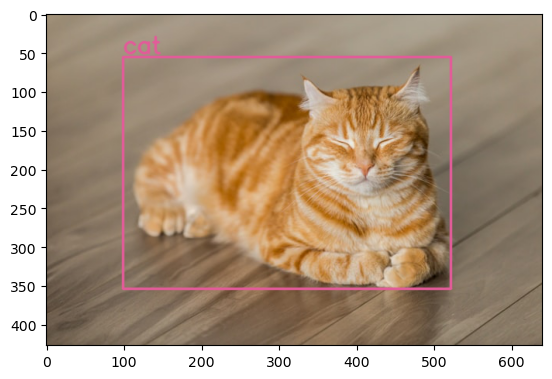

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'


# 로컬에서 이미지 로드
pil_image = Image.open("sample.jpg").convert("RGB") #파이썬 이미지로 만들었고

# 이미지 변환
transformed_image = transform(pil_image) 
transformed_image = transformed_image.unsqueeze(0)  # [C, H, W] -> [1, C, H, W] 차원+1
transformed_image = transformed_image.to(device) #gpu 설정

# 예측 수행 (바운딩 박스, 레이블)
boxes, labels = predict(transformed_image, model, device, 0.7) #임계값 0.7 이상!!!

# 바운딩 박스 그리기
numpy_image = np.array(pil_image) 
draw_boxes(boxes, labels, numpy_image) #이미지+박스+이름

# 이미지 표시
plt.imshow(numpy_image)
plt.show() 


원격 이미지에서 그려보기

이미지를 저장하지 않고 하는 작업 방식으로

# 이미지 URL
url = "https://images.unsplash.com/photo-1485182708500-e8f1f318ba72?w=1000"

# 다운로드 진행 상황 표시
with tqdm(unit="B", unit_scale=True, miniters=1, desc="Downloading Image") as progress:
    res = request.urlopen(url)
    total_size = int(res.info().get("Content-Length", -1)) #사이즈

    # 이미지를 읽어오면서 진행 상황 업데이트
    buffer = BytesIO()
    downloaded_size = 0
    block_size = 8192 #한번에 읽어오는 것
    while True: 
        buffer_chunk = res.read(block_size)
        if not buffer_chunk: #없으면 break
            break
        downloaded_size += len(buffer_chunk) 
        buffer.write(buffer_chunk) 
        progress.update(len(buffer_chunk)) #이미지를 읽어오면서 이미지상황 업데이트

# 이미지 데이터로부터 PIL 이미지 생성
buffer.seek(0) 
buffered_image = Image.open(buffer)

이게 이미지 가지고 오는 구간.

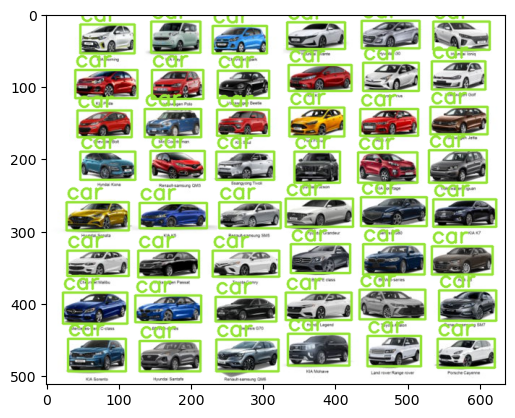

In [13]:
from urllib import request
from io import BytesIO
from tqdm import tqdm

# 이미지 URL
# url = "https://images.unsplash.com/photo-1485182708500-e8f1f318ba72?w=1000"
url = "https://search.pstatic.net/common/?src=http%3A%2F%2Fblogfiles.naver.net%2FMjAyNTA1MTlfMTcz%2FMDAxNzQ3NjMyOTYwNDgy.WTGWMTyNei0z3crvSbMixGGwaExRYxkKcm5925ztPDYg.9DJRAKh_B2xtFv1E14nd9IPgXLcLZXmiGD5QWo9vCuEg.PNG%2F%25C0%25DA%25B5%25BF%25C2%25F7_5.png&type=sc960_832"


# 다운로드 진행 상황 표시
with tqdm(unit="B", unit_scale=True, miniters=1, desc="Downloading Image") as progress:
    res = request.urlopen(url)
    total_size = int(res.info().get("Content-Length", -1)) #사이즈

    # 이미지를 읽어오면서 진행 상황 업데이트
    buffer = BytesIO()
    downloaded_size = 0
    block_size = 8192 #한번에 읽어오는 것
    while True: 
        buffer_chunk = res.read(block_size)
        if not buffer_chunk: #없으면 break
            break
        downloaded_size += len(buffer_chunk) 
        buffer.write(buffer_chunk) 
        progress.update(len(buffer_chunk)) #이미지를 읽어오면서 이미지상황 업데이트

# 이미지 데이터로부터 PIL 이미지 생성
buffer.seek(0) 
buffered_image = Image.open(buffer)

# 이미지 변환
transformed_image = transform(buffered_image)
transformed_image = transformed_image.unsqueeze(0)
transformed_image = transformed_image.to(device)

# 예측 수행 (바운딩 박스, 레이블)
boxes, labels = predict(transformed_image, model, device, 0.9)

# 바운딩 박스 그리기
numpy_image = np.array(buffered_image)
draw_boxes(boxes, labels, numpy_image)

# 이미지 표시
plt.imshow(numpy_image)
plt.show()


동영상 재생하면서 객체 검출하기
동영상에서 20초 프래임당 그려지는게 많아지니 중간에 멈추기

샘플 동영상 다운로드

In [10]:
import requests

# 동영상 URL
url = "https://cdn.pixabay.com/video/2020/05/22/39836-424360861_tiny.mp4"

# 로컬 파일 이름 설정
file_name = "sample.mp4"

# 동영상 다운로드 요청
response = requests.get(url)

# 다운로드 성공 여부 확인
if response.status_code == 200:
    # 동영상을 로컬 파일로 저장
    with open(file_name, "wb") as f:
        f.write(response.content)
    print("동영상을 성공적으로 저장되었습니다.")
else:
    print("동영상을 다운로드하는 데 문제가 발생했습니다. 상태 코드:", response.status_code)


동영상을 성공적으로 저장되었습니다.


 동영상 재생하면서 객체 검출하기

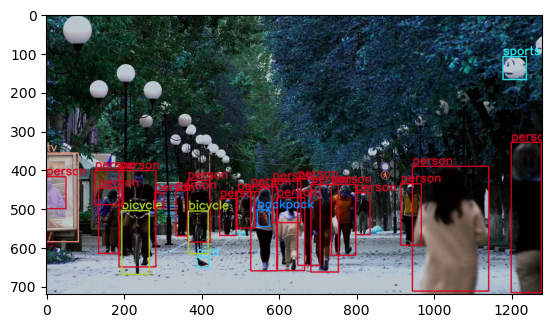

KeyboardInterrupt: 

In [11]:
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, clear_output

def predict_on_video(video_path, model, device, confidence_threshold=0.8):
    cap = cv2.VideoCapture(video_path)

    # 동영상 파일 열기 실패 시
    if not cap.isOpened():
        print("오류! 동영상을 재생할 수 없습니다.")
        return

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # 프레임을 PIL 이미지로 변환
        pil_image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

        # 이미지 변환
        transformed_image = transform(pil_image)
        transformed_image = transformed_image.unsqueeze(0)
        transformed_image = transformed_image.to(device)

        # 예측 수행 (바운딩 박스, 레이블)
        boxes, labels = predict(transformed_image, model, device, 0.7)

        # 바운딩 박스 그리기
        numpy_image = np.array(pil_image)
        draw_boxes(boxes, labels, frame)

        # 실시간 비디오 스트림 표시
        clear_output(wait=True)
        plt.imshow(frame)
        plt.show()

    cap.release()
    cv2.destroyAllWindows()

# 동영상 경로 설정
video_path = "sample.mp4"
predict_on_video(video_path, model, device)


동영상 내용을 캡쳐할수도 있어.